# Model Training
Two models on the same feature matrix:
1. **MultiOutputClassifier(XGBoost)** — predicts all 6 damage types
2. **XGBRegressor** — predicts repair cost

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from xgboost import XGBClassifier, XGBRegressor
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, hamming_loss, jaccard_score,
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report
)

PROC_ROOT    = r'..\data\processed'
MODELS_DIR   = r'..\models'
os.makedirs(MODELS_DIR, exist_ok=True)

DAMAGE_TYPES = ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']
FLAG_COLS    = [f'has_{d}' for d in DAMAGE_TYPES]

print('Setup complete.')

Setup complete.


## 1. Load Features and Annotations

In [2]:
features  = np.load(os.path.join(PROC_ROOT, 'image_features.npy'))   # (4000, 2048)
image_ids = np.load(os.path.join(PROC_ROOT, 'image_ids.npy'))         # (4000,)
df        = pd.read_csv(os.path.join(PROC_ROOT, 'annotations.csv'))

# Align features with annotations using image_id
id_to_idx = {img_id: idx for idx, img_id in enumerate(image_ids)}
df['feat_idx'] = df['image_id'].map(id_to_idx)
df = df.dropna(subset=['feat_idx']).reset_index(drop=True)
df['feat_idx'] = df['feat_idx'].astype(int)

features = features[df['feat_idx'].values]  # reorder to match df

print(f'Features shape : {features.shape}')
print(f'Annotations    : {df.shape}')
df.head(3)

Features shape : (4000, 2048)
Annotations    : (4000, 13)


,image_id,file_name,split,damage_count,total_damage_area,dominant_damage,has_dent,has_scratch,has_crack,has_glass_shatter,has_lamp_broken,has_tire_flat,feat_idx
0,1,000001.jpg,train2017,2,312326.0,tire flat,0,1,0,0,0,1,0
1,2,000002.jpg,train2017,1,114126.0,tire flat,0,0,0,0,0,1,1
2,3,000003.jpg,train2017,1,299792.0,tire flat,0,0,0,0,0,1,2


## 2. Generate Synthetic Car Metadata

In [3]:
rng = np.random.default_rng(seed=42)

MAKES = ['Toyota', 'Honda', 'BMW', 'Mercedes', 'Ford', 'Hyundai', 'Audi', 'Chevrolet']
MAKE_FACTOR = {
    'BMW': 1.5, 'Mercedes': 1.5, 'Audi': 1.5,
    'Ford': 1.1, 'Chevrolet': 1.1,
    'Toyota': 1.0, 'Honda': 1.0, 'Hyundai': 1.0
}

df['make'] = rng.choice(MAKES, size=len(df))
df['year'] = rng.integers(2005, 2025, size=len(df))
df['car_age'] = 2025 - df['year']

# Encode make as integer for XGBoost
le = LabelEncoder()
df['make_encoded'] = le.fit_transform(df['make'])

print('Car metadata added:')
print(df[['make', 'year', 'car_age', 'make_encoded']].head(5))

Car metadata added:
       make  year  car_age  make_encoded
0    Toyota  2011       14             7
1      Audi  2021        4             0
2   Hyundai  2005       20             5
3  Mercedes  2013       12             6
4  Mercedes  2021        4             6


## 3. Generate Synthetic Repair Cost (Regression Target)

In [4]:
BASE_COST = {
    'tire_flat': 800, 'glass_shatter': 600, 'lamp_broken': 400,
    'crack': 300, 'dent': 200, 'scratch': 100
}

# Sum base costs of all damage types present per image
df['base_cost'] = sum(df[f'has_{d}'] * BASE_COST[d] for d in DAMAGE_TYPES)

# Area multiplier — larger damage = higher cost
df['area_multiplier'] = 1 + (df['total_damage_area'] / 50000)

# Car age factor — newer cars cost more to repair
df['age_factor'] = 1 + (1 / df['car_age'].clip(lower=1))

# Make factor
df['make_factor'] = df['make'].map(MAKE_FACTOR)

# Final repair cost + 10% random noise
noise = rng.uniform(0.9, 1.1, size=len(df))
df['repair_cost'] = (df['base_cost'] * df['area_multiplier'] * df['age_factor'] * df['make_factor'] * noise).round(2)

print(f'Repair cost stats:')
print(df['repair_cost'].describe().round(2))

Repair cost stats:
count     4000.00
mean      3098.17
std       3439.00
min        103.30
25%        556.81
50%       1655.15
75%       4674.43
max      25351.71
Name: repair_cost, dtype: float64


## 4. Build Final Feature Matrix

In [5]:
# FLAG_COLS removed from X — they are the targets (y_class), not inputs.
# Including them leaks the answers directly into the model (causes perfect F1 = 1.0).
tabular_cols = ['total_damage_area', 'damage_count', 'make_encoded', 'car_age']
tabular = df[tabular_cols].values   # (4000, 4)

X       = np.concatenate([features, tabular], axis=1)  # (4000, 2052)
y_class = df[FLAG_COLS].values                         # (4000, 6)
y_reg   = df['repair_cost'].values                     # (4000,)

print(f'Feature matrix X : {X.shape}')
print(f'Classification y : {y_class.shape}')
print(f'Regression y     : {y_reg.shape}')
print(f'2048 image + {tabular.shape[1]} tabular = {X.shape[1]} total features')

Feature matrix X : (4000, 2052)
Classification y : (4000, 6)
Regression y     : (4000,)
2048 image + 4 tabular = 2052 total features


## 5. Train / Val / Test Split

In [6]:
# Use the split column from annotations.csv — same split as original dataset
train_mask = df['split'] == 'train2017'
val_mask   = df['split'] == 'val2017'
test_mask  = df['split'] == 'test2017'

X_train, X_val, X_test = X[train_mask], X[val_mask], X[test_mask]

y_cls_train, y_cls_val, y_cls_test = y_class[train_mask], y_class[val_mask], y_class[test_mask]
y_reg_train, y_reg_val, y_reg_test = y_reg[train_mask],   y_reg[val_mask],   y_reg[test_mask]

print(f'Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}')

Train: 2816 | Val: 810 | Test: 374


## 6. Model A — Multi-Label Damage Classification

In [7]:
clf = MultiOutputClassifier(
    XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='logloss',
        random_state=42,
        verbosity=0
    )
)

clf.fit(X_train, y_cls_train)
print('Classifier trained.')

Classifier trained.


In [8]:
y_pred_cls = clf.predict(X_test)

print('=== Multi-Label Classification Results (Test Set) ===')
print(f'Hamming Loss  : {hamming_loss(y_cls_test, y_pred_cls):.4f}  (lower is better)')
print(f'Jaccard Score : {jaccard_score(y_cls_test, y_pred_cls, average="samples"):.4f}  (higher is better)')
print(f'F1 Micro      : {f1_score(y_cls_test, y_pred_cls, average="micro"):.4f}')
print(f'F1 Macro      : {f1_score(y_cls_test, y_pred_cls, average="macro"):.4f}')
print()
print('Per-class F1:')
f1_per = f1_score(y_cls_test, y_pred_cls, average=None)
for label, score in zip(FLAG_COLS, f1_per):
    print(f'  {label:<22} F1 = {score:.4f}')

=== Multi-Label Classification Results (Test Set) ===
Hamming Loss  : 0.0998  (lower is better)
Jaccard Score : 0.7251  (higher is better)
F1 Micro      : 0.7918
F1 Macro      : 0.7497

Per-class F1:
  has_dent               F1 = 0.7950
  has_scratch            F1 = 0.8308
  has_crack              F1 = 0.3881
  has_glass_shatter      F1 = 0.9333
  has_lamp_broken        F1 = 0.6786
  has_tire_flat          F1 = 0.8727


## 7. Model B — Repair Cost Regression

In [9]:
reg = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    eval_metric='rmse',
    random_state=42,
    verbosity=0
)

reg.fit(X_train, y_reg_train,
        eval_set=[(X_val, y_reg_val)],
        verbose=False)

print('Regressor trained.')

Regressor trained.


=== Repair Cost Regression Results (Test Set) ===
MAE  : $840.36   (avg dollar error)
RMSE : $1214.14  (penalises large errors more)
R²   : 0.8571    (1.0 = perfect, 0 = baseline mean)


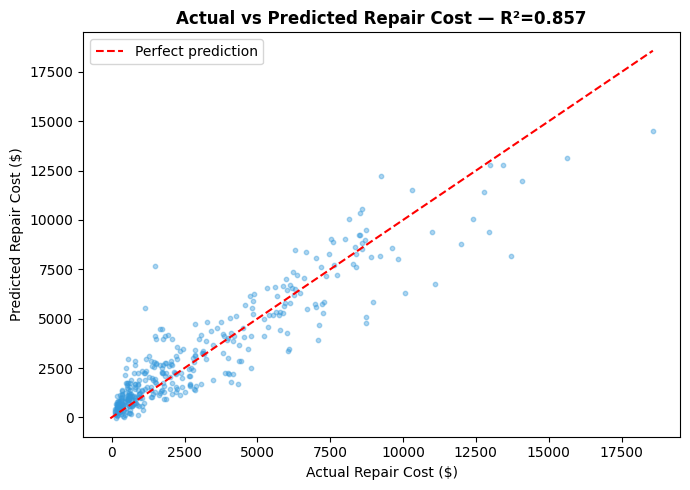

In [10]:
y_pred_reg = reg.predict(X_test)

mae  = mean_absolute_error(y_reg_test, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg))
r2   = r2_score(y_reg_test, y_pred_reg)

print('=== Repair Cost Regression Results (Test Set) ===')
print(f'MAE  : ${mae:.2f}   (avg dollar error)')
print(f'RMSE : ${rmse:.2f}  (penalises large errors more)')
print(f'R²   : {r2:.4f}    (1.0 = perfect, 0 = baseline mean)')

# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_reg_test, y_pred_reg, alpha=0.4, s=10, color='#3498db')
lims = [min(y_reg_test.min(), y_pred_reg.min()),
        max(y_reg_test.max(), y_pred_reg.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Repair Cost ($)')
ax.set_ylabel('Predicted Repair Cost ($)')
ax.set_title(f'Actual vs Predicted Repair Cost — R²={r2:.3f}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save Models

In [11]:
joblib.dump(clf, os.path.join(MODELS_DIR, 'damage_classifier.pkl'))
reg.save_model(os.path.join(MODELS_DIR, 'repair_cost_regressor.json'))
joblib.dump(le,  os.path.join(MODELS_DIR, 'make_label_encoder.pkl'))

print('Saved:')
print(f'  models/damage_classifier.pkl')
print(f'  models/repair_cost_regressor.json')
print(f'  models/make_label_encoder.pkl')

Saved:
  models/damage_classifier.pkl
  models/repair_cost_regressor.json
  models/make_label_encoder.pkl
